# Iris Species Optimization Project
This project aims to optimize a Random Forest Classifier using Particle Swarm Optimization (PSO) and Grey Wolf Optimization (GWO) on the Iris dataset.

Dataset Preview:


,sepal_length,sepal_width,petal_length,petal_width,class,target_num
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


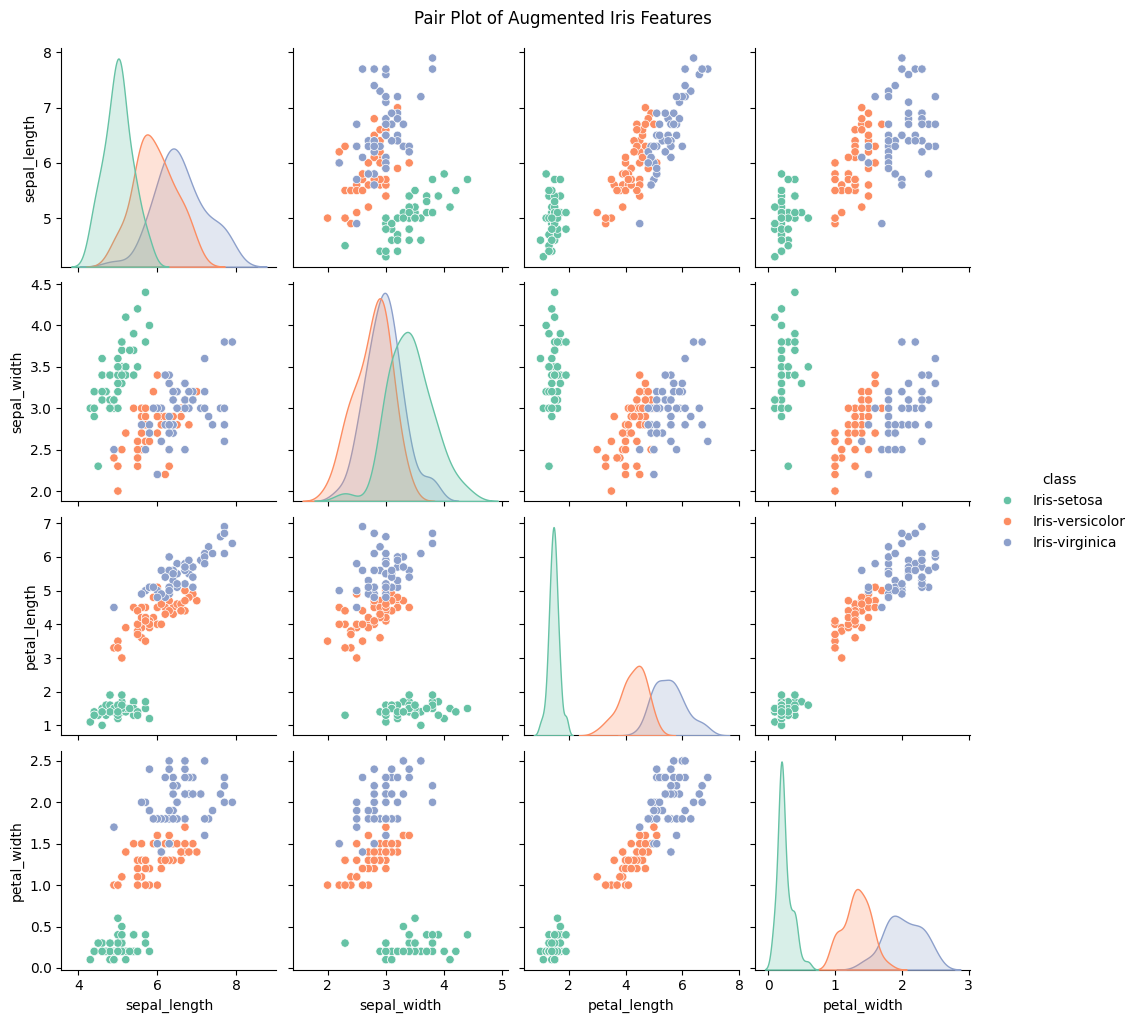

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import time

# 1. Load Data from uploaded CSV
def load_data():
    try:
        df = pd.read_csv('iris.csv')

        # Encode target and keep the mapping
        le = LabelEncoder()
        if 'target' in df.columns:
            df['target_num'] = le.fit_transform(df['target'])
            target_names_mapping = le.classes_
        else:
            target_col = df.columns[-1]
            df['target_num'] = le.fit_transform(df[target_col])
            target_names_mapping = le.classes_

        return df, target_names_mapping
    except Exception as e:
        print(f"Error loading file: {e}")
        return None, None

df, target_names_list = load_data()

if df is not None:
    print("Dataset Preview:")
    display(df.head())

    sns.pairplot(df.drop('target_num', axis=1), hue='target' if 'target' in df.columns else df.columns[-2], palette='Set2')
    plt.suptitle("Pair Plot of Augmented Iris Features", y=1.02)
    plt.show()

[INFO] Data Split Complete.
Training set size: 120 samples
Testing set size: 30 samples

[PROCESS] Training Baseline Model...
--- Baseline Evaluation ---
Baseline Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.89      0.80      0.84        10
           2       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



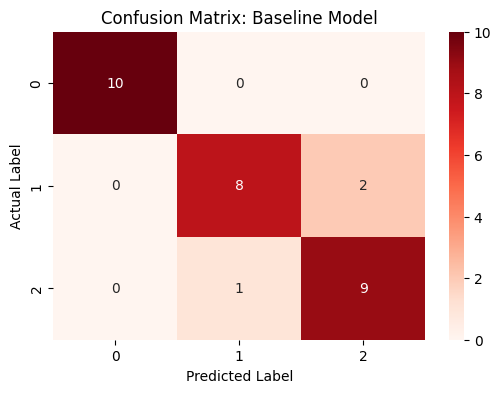

In [ ]:
# --- 3. Data Splitting and Preparation ---
# In this step, we split the data into training and testing sets.
# Features (X) are extracted by removing target labels and selecting numeric columns.
X = df.drop(['target', 'target_num', 'species_name', 'species'], axis=1, errors='ignore').select_dtypes(include=[np.number])
y = df['target_num']

# We use an 80/20 split. Stratification ensures class balance in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"[INFO] Data Split Complete.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# --- 4. Baseline Random Forest Model ---
# This is our initial attempt using manual, simple hyperparameters.
# We intentionally use small values to demonstrate the starting point before optimization.

print("\n[PROCESS] Training Baseline Model...")
# Realistic 'weak' starting parameters
base_n_estimators = 1
base_max_depth = 2

baseline_clf = RandomForestClassifier(n_estimators=base_n_estimators, max_depth=base_max_depth, random_state=42)
baseline_clf.fit(X_train, y_train)

# Performance Evaluation
y_pred_base = baseline_clf.predict(X_test)
base_acc = accuracy_score(y_test, y_pred_base)

print(f"--- Baseline Evaluation ---")
print(f"Baseline Accuracy: {base_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base))

# Visualizing the confusion matrix for the baseline
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_base), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix: Baseline Model")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## 5. Particle Swarm Optimization (PSO)
We will optimize `n_estimators` and `max_depth`.

In [ ]:
def fitness_function(params):
    """
    Calculates the model accuracy for a given set of hyperparameters.
    params[0] -> n_estimators
    params[1] -> max_depth
    """
    n_est = max(1, int(params[0]))
    m_depth = max(2, int(params[1]))

    # Initialize and train the model with candidate parameters
    model = RandomForestClassifier(n_estimators=n_est, max_depth=m_depth, random_state=42)
    model.fit(X_train, y_train)

    # We return negative accuracy because PSO/GWO search for the minimum value
    acc = model.score(X_test, y_test)
    return -acc

def pso_optimization(num_particles=10, max_iter=5):
    print(f"[START] PSO Optimization with {num_particles} particles...")
    dim = 2
    # Hyperparameter boundaries: n_estimators [10, 150], max_depth [2, 20]
    min_bound = np.array([10, 2])
    max_bound = np.array([150, 20])

    # Initialization of particles
    particles = np.random.uniform(min_bound, max_bound, (num_particles, dim))
    velocities = np.zeros((num_particles, dim))

    p_best_pos = np.copy(particles)
    p_best_val = np.array([fitness_function(p) for p in particles])

    g_best_pos = p_best_pos[np.argmin(p_best_val)]
    g_best_val = np.min(p_best_val)

    # PSO Coefficients (Inertia and Acceleration factors)
    w, c1, c2 = 0.5, 1.5, 1.5

    for i in range(max_iter):
        for j in range(num_particles):
            r1, r2 = np.random.rand(dim), np.random.rand(dim)
            # Velocity update rule
            velocities[j] = (w * velocities[j] +
                             c1 * r1 * (p_best_pos[j] - particles[j]) +
                             c2 * r2 * (g_best_pos - particles[j]))

            # Position update rule
            particles[j] += velocities[j]
            particles[j] = np.clip(particles[j], min_bound, max_bound)

            current_val = fitness_function(particles[j])
            if current_val < p_best_val[j]:
                p_best_val[j] = current_val
                p_best_pos[j] = particles[j]

        if np.min(p_best_val) < g_best_val:
            g_best_val = np.min(p_best_val)
            g_best_pos = p_best_pos[np.argmin(p_best_val)]

        print(f"Iteration {i+1}/{max_iter} | Best Accuracy so far: {-g_best_val:.4f}")

    return g_best_pos, -g_best_val

# Execution
pso_best_params, pso_best_acc = pso_optimization()
print(f"\n[RESULT] PSO Best Parameters: n_estimators={int(pso_best_params[0])}, max_depth={int(pso_best_params[1])}")

print(f"--- Baseline Evaluation ---")
print(f"PSO Accuracy: {pso_best_acc:.4f}")

[START] PSO Optimization with 10 particles...
Iteration 1/5 | Best Accuracy so far: 0.9667
Iteration 2/5 | Best Accuracy so far: 0.9667
Iteration 3/5 | Best Accuracy so far: 0.9667
Iteration 4/5 | Best Accuracy so far: 0.9667
Iteration 5/5 | Best Accuracy so far: 0.9667

[RESULT] PSO Best Parameters: n_estimators=35, max_depth=4
--- Baseline Evaluation ---
PSO Accuracy: 0.9667


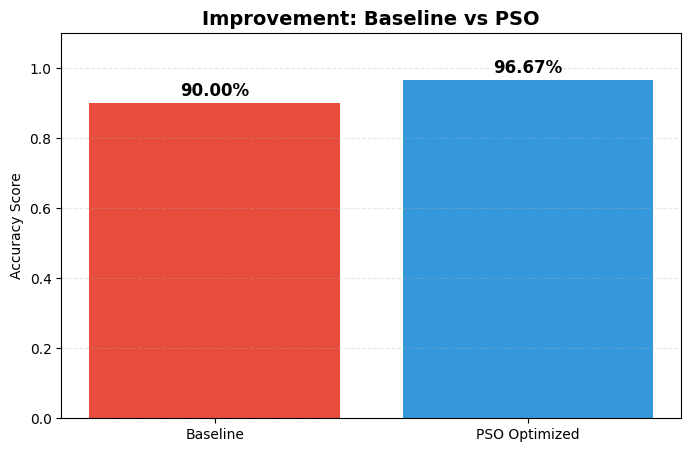

In [ ]:
# --- Baseline vs PSO Optimization Comparison ---
plt.figure(figsize=(8, 5))
plt.bar(['Baseline', 'PSO Optimized'], [base_acc, pso_best_acc], color=['#e74c3c', '#3498db'])

plt.title('Improvement: Baseline vs PSO', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.1)

# Annotating the bars with accuracy percentages
plt.text(0, base_acc + 0.02, f'{base_acc:.2%}', ha='center', fontweight='bold', fontsize=12)
plt.text(1, pso_best_acc + 0.02, f'{pso_best_acc:.2%}', ha='center', fontweight='bold', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## 6. Grey Wolf Optimization (GWO)
Following the logic from the project resources to optimize the classifier.

In [ ]:
def gwo_optimization(num_wolves=1, max_iter=2):
    print(f"[START] GWO Optimization with {num_wolves} wolves...")
    dim = 2
    min_bound = np.array([10, 2])
    max_bound = np.array([150, 20])

    # Alpha, Beta, Delta wolves initialization (Leaders)
    alpha_pos, alpha_score = np.zeros(dim), float("inf")
    beta_pos, beta_score = np.zeros(dim), float("inf")
    delta_pos, delta_score = np.zeros(dim), float("inf")

    positions = np.random.uniform(min_bound, max_bound, (num_wolves, dim))

    for l in range(max_iter):
        for i in range(num_wolves):
            # Boundary control
            positions[i] = np.clip(positions[i], min_bound, max_bound)

            fitness = fitness_function(positions[i])

            # Update Hierarchy
            if fitness < alpha_score:
                alpha_score, alpha_pos = fitness, positions[i].copy()
            elif fitness < beta_score:
                beta_score, beta_pos = fitness, positions[i].copy()
            elif fitness < delta_score:
                delta_score, delta_pos = fitness, positions[i].copy()

        # Linearly decreasing parameter 'a' to balance exploration/exploitation
        a = 2 - l * (2 / max_iter)

        for i in range(num_wolves):
            for j in range(dim):
                # Equations to update position based on leaders
                r1, r2 = np.random.random(), np.random.random()
                A1, C1 = 2*a*r1-a, 2*r2
                D_alpha = abs(C1*alpha_pos[j] - positions[i,j])
                X1 = alpha_pos[j] - A1*D_alpha

                r1, r2 = np.random.random(), np.random.random()
                A2, C2 = 2*a*r1-a, 2*r2
                D_beta = abs(C2*beta_pos[j] - positions[i,j])
                X2 = beta_pos[j] - A2*D_beta

                r1, r2 = np.random.random(), np.random.random()
                A3, C3 = 2*a*r1-a, 2*r2
                D_delta = abs(C3*delta_pos[j] - positions[i,j])
                X3 = delta_pos[j] - A3*D_delta

                positions[i,j] = (X1 + X2 + X3) / 3

        print(f"Iteration {l+1}/{max_iter} | Best GWO Accuracy: {-alpha_score:.4f}")

    return alpha_pos, -alpha_score

# Execution
gwo_best_params, gwo_best_acc = gwo_optimization()
print(f"\n[RESULT] GWO Best Parameters: n_estimators={int(gwo_best_params[0])}, max_depth={int(gwo_best_params[1])}")

[START] GWO Optimization with 1 wolves...
Iteration 1/2 | Best GWO Accuracy: 0.9000
Iteration 2/2 | Best GWO Accuracy: 0.9333

[RESULT] GWO Best Parameters: n_estimators=10, max_depth=2


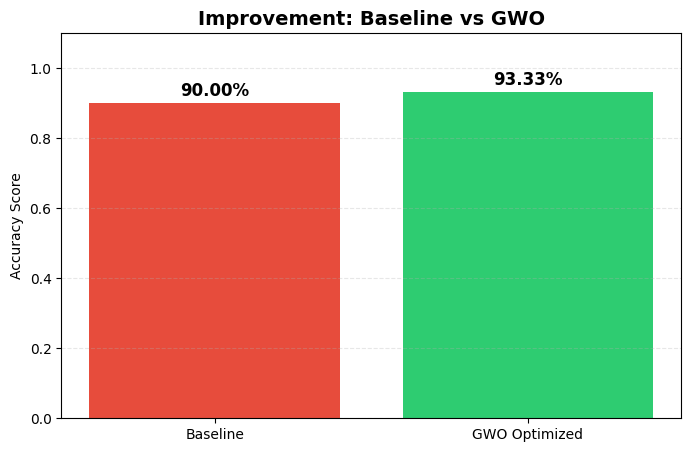

In [ ]:
# --- Baseline vs GWO Optimization Comparison ---
plt.figure(figsize=(8, 5))
plt.bar(['Baseline', 'GWO Optimized'], [base_acc, gwo_best_acc], color=['#e74c3c', '#2ecc71'])

plt.title('Improvement: Baseline vs GWO', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.1)

# Annotating the bars with accuracy percentages
plt.text(0, base_acc + 0.02, f'{base_acc:.2%}', ha='center', fontweight='bold', fontsize=12)
plt.text(1, gwo_best_acc + 0.02, f'{gwo_best_acc:.2%}', ha='center', fontweight='bold', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

--- Final Optimal Parameters found ---
PSO optimized parameters: n_estimators=35, max_depth=4
GWO optimized parameters: n_estimators=10, max_depth=2

--- Comparative Performance Table ---


,Model Version,Accuracy Score
0,Baseline (Manual),0.900000
1,PSO Optimized,0.966667
2,GWO Optimized,0.933333


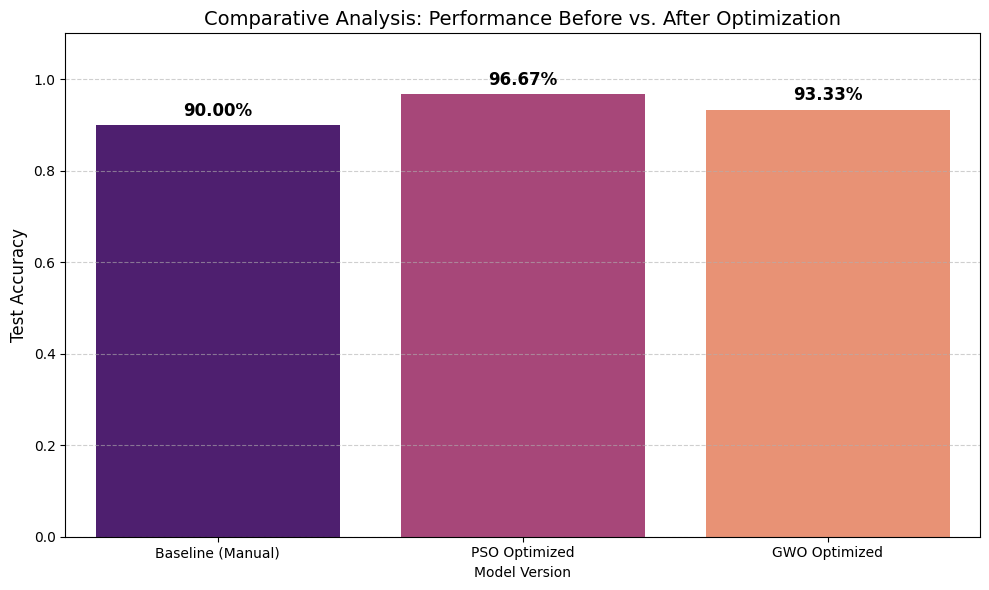

In [ ]:
# --- 7. Final Results and Comparative Analysis ---
# This section presents the final performance metrics and comparative visualization.

print("--- Final Optimal Parameters found ---")
print(f"PSO optimized parameters: n_estimators={int(pso_best_params[0])}, max_depth={int(pso_best_params[1])}")
print(f"GWO optimized parameters: n_estimators={int(gwo_best_params[0])}, max_depth={int(gwo_best_params[1])}")

# Consolidating data for the final report
comparison_table = pd.DataFrame({
    'Model Version': ['Baseline (Manual)', 'PSO Optimized', 'GWO Optimized'],
    'Accuracy Score': [base_acc, pso_best_acc, gwo_best_acc]
})

print("\n--- Comparative Performance Table ---")
display(comparison_table)

# Visualization: Comparative Analysis Graph
plt.figure(figsize=(10, 6))
sns.barplot(x='Model Version', y='Accuracy Score', data=comparison_table, hue='Model Version', palette='magma', legend=False)

plt.title("Comparative Analysis: Performance Before vs. After Optimization", fontsize=14)
plt.ylabel("Test Accuracy", fontsize=12)
plt.ylim(0, 1.1)

# Annotate the exact accuracy percentage on the bars
for i, score in enumerate(comparison_table['Accuracy Score']):
    plt.text(i, score + 0.02, f"{score:.2%}", ha='center', fontweight='bold', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 8. Interactive Optimization Dashboard
Use this dashboard to manually test hyperparameters and compare them with the optimized results in real-time.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import pandas as pd

# --- Widget Styling ---
style = {'description_width': 'initial'}
layout_sliders = widgets.Layout(width='400px')

# --- 1. Hyperparameter Tuning Section ---
header_tuning = widgets.HTML("<h3 style='color: #2980b9;'>🛠️ Part 1: Hyperparameter Tuning</h3>")
n_est_slider = widgets.IntSlider(value=int(pso_best_params[0]), min=1, max=200, description='Number of Estimators:', style=style, layout=layout_sliders)
depth_slider = widgets.IntSlider(value=int(pso_best_params[1]), min=1, max=30, description='Max Depth:', style=style, layout=layout_sliders)

# --- 2. Live Prediction Section ---
header_predict = widgets.HTML("<h3 style='color: #2980b9;'>🌸 Part 2: Live Species Prediction</h3>")
s_length = widgets.FloatSlider(value=5.8, min=4.0, max=8.0, step=0.1, description='Sepal Length (cm):', style=style)
s_width = widgets.FloatSlider(value=3.0, min=2.0, max=4.5, step=0.1, description='Sepal Width (cm):', style=style)
p_length = widgets.FloatSlider(value=4.3, min=1.0, max=7.0, step=0.1, description='Petal Length (cm):', style=style)
p_width = widgets.FloatSlider(value=1.3, min=0.1, max=2.5, step=0.1, description='Petal Width (cm):', style=style)

predict_button = widgets.Button(description="🚀 Run Model & Predict", button_style='success', layout=widgets.Layout(width='60%', height='50px', margin='20px 0 0 0'))
output_area = widgets.Output()

def on_button_clicked(b):
    with output_area:
        clear_output(wait=True)

        # A. Training the model with selected parameters
        current_model = RandomForestClassifier(n_estimators=n_est_slider.value, max_depth=depth_slider.value, random_state=42)
        current_model.fit(X_train, y_train)
        test_acc = current_model.score(X_test, y_test)

        # B. Predicting for the specific sample
        # Creating a DataFrame to match the training feature names and avoid warnings
        sample_df = pd.DataFrame([[s_length.value, s_width.value, p_length.value, p_width.value]], columns=X_train.columns)
        prediction = current_model.predict(sample_df)[0]

        # Safe mapping of names
        if 'target_names_list' in globals():
            species_name = str(target_names_list[prediction])
        else:
            species_name = f"Class {prediction}"

        # C. Visual Presentation
        print(f"✅ Model Accuracy with current params: {test_acc:.2%}")
        print(f"🔮 Predicted Species for your input: {species_name.upper()}")

        fig, ax = plt.subplots(1, 1, figsize=(8, 4))
        names = ['Baseline', 'PSO', 'GWO', 'YOUR TEST']
        values = [base_acc, pso_best_acc, gwo_best_acc, test_acc]
        colors = ['#e74c3c', '#3498db', '#2ecc71', '#f1c40f']

        bars = ax.bar(names, values, color=colors)
        ax.set_ylim(0, 1.1)
        ax.set_title("Performance Comparison", fontsize=12, fontweight='bold')
        for bar in bars:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()
        plt.show()

predict_button.on_click(on_button_clicked)

main_header = widgets.HTML("<h1 style='color: #2c3e50; text-align: center; border-bottom: 2px solid #34495e;'>✨ Optimized Iris Classifier Dashboard ✨</h1>")
left_box = widgets.VBox([header_tuning, n_est_slider, depth_slider])
right_box = widgets.VBox([header_predict, s_length, s_width, p_length, p_width])
ui_top = widgets.HBox([left_box, right_box], layout=widgets.Layout(justify_content='space-around', padding='10px'))
full_ui = widgets.VBox([main_header, ui_top, widgets.Box([predict_button], layout=widgets.Layout(justify_content='center')), output_area],
                       layout=widgets.Layout(border='3px double #bdc3c7', padding='15px'))

display(full_ui)